## Allan Variace

carlibation of the IMU, [reference example](https://github.com/nmayorov/allan-variance/blob/master/example.ipynb)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import allan_variance

In [2]:
def read_imu_data(file_path):
    imu_data = []  # List to store the extracted data

    # Open the file and read line by line
    with open(file_path, 'r') as file:
        for line in file:
            # Check if the line starts with 'imu'
            if line.startswith('imu'):
                # Split the line into components
                parts = line.strip().split()
                if len(parts) == 8:  # Ensure the line has the correct number of elements
                    # Extract the data
                    time = int(parts[1])  # Time in microseconds
                    ax = float(parts[2])
                    ay = float(parts[3])
                    az = float(parts[4])
                    gx = float(parts[5])
                    gy = float(parts[6])
                    gz = float(parts[7])

                    # Store the data in a dictionary
                    data_dict = {
                        'time': time,
                        'ax': ax,
                        'ay': ay,
                        'az': az,
                        'gx': gx,
                        'gy': gy,
                        'gz': gz
                    }

                    # Append the dictionary to the list
                    imu_data.append(data_dict)

    return imu_data

In [3]:
file_path = '../data/mobili_18.record'  # Replace with your file path
imu_data = read_imu_data(file_path)

In [7]:
# Extract time and sensor data
times = np.array([data['time'] for data in imu_data])
ax_data = np.array([data['ax'] for data in imu_data])
ay_data = np.array([data['ay'] for data in imu_data])
az_data = np.array([data['az'] for data in imu_data])
gx_data = np.array([data['gx'] for data in imu_data])
gy_data = np.array([data['gy'] for data in imu_data])
gz_data = np.array([data['gz'] for data in imu_data])
dt = np.diff(times) / 1e6  # Convert microseconds to seconds

In [45]:
def compute_allan(name, data, dt):
    data_length = data.shape[0]
    begin = int(data_length * 0.1)
    end = data_length - begin
    sub_data = data[begin : end]
    tau, avar = allan_variance.compute_avar(sub_data, dt)
    params, avar_pred = allan_variance.estimate_parameters(tau, avar)
    print("    ", name, "    ")
    print(params)
    
    plt.loglog(tau, avar, '.', label='Computed')
    plt.loglog(tau, avar_pred, label='Modeled with estimated parameters')
    plt.legend()
    plt.xlabel("Averaging time, s")
    plt.ylabel("AVAR")

     ax     
quantization    0.000000
white           0.000606
flicker         0.000751
walk            0.000070
ramp            0.000004
Name: 0, dtype: float64
     ay     
quantization    0.000000e+00
white           1.021606e-03
flicker         1.069541e-03
walk            4.106218e-05
ramp            5.315736e-07
Name: 0, dtype: float64
     az     
quantization    0.000000
white           0.001065
flicker         0.000699
walk            0.000061
ramp            0.000002
Name: 0, dtype: float64
     gx     
quantization    0.000000
white           0.000006
flicker         0.000095
walk            0.000019
ramp            0.000000
Name: 0, dtype: float64
     gy     
quantization    0.000000e+00
white           6.940665e-06
flicker         8.226552e-05
walk            2.898568e-06
ramp            1.703159e-08
Name: 0, dtype: float64
     gz     
quantization    0.000000e+00
white           4.828387e-06
flicker         1.506914e-04
walk            1.850299e-05
ramp            2.334

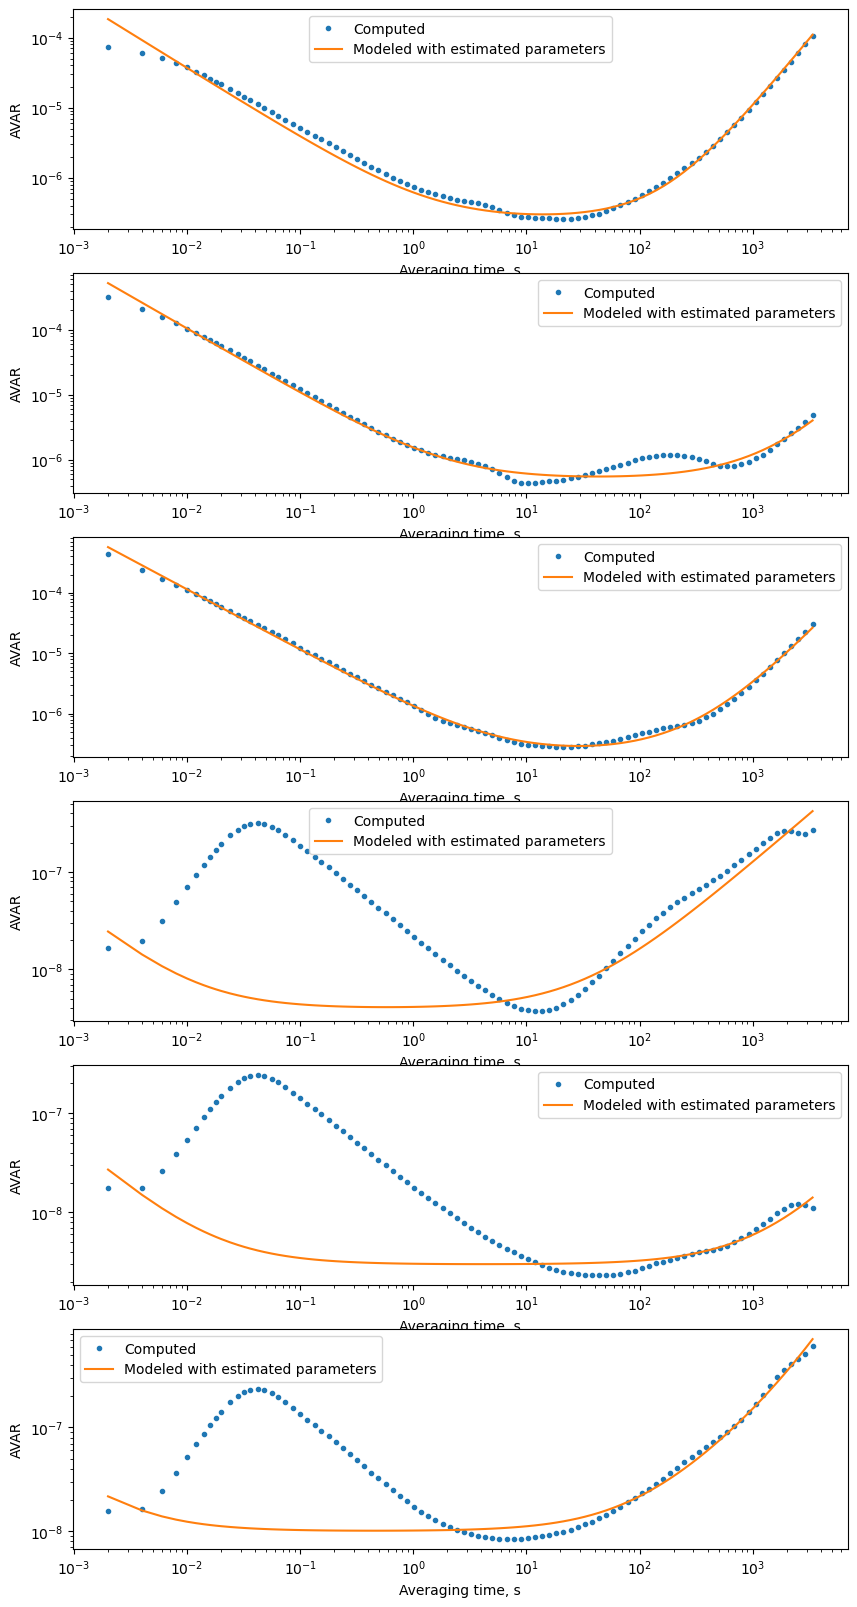

In [46]:
plt.figure(figsize=(10, 20))
plt.subplot(6, 1, 1)
compute_allan("ax", ax_data, 0.002)
plt.subplot(6, 1, 2)
compute_allan("ay", ay_data, 0.002)
plt.subplot(6, 1, 3)
compute_allan("az", az_data, 0.002)

plt.subplot(6, 1, 4)
compute_allan("gx", gx_data, 0.002)
plt.subplot(6, 1, 5)
compute_allan("gy", gy_data, 0.002)
plt.subplot(6, 1, 6)
compute_allan("gz", gz_data, 0.002)